# Analyze Saved Runs

Loads one or more runs previously produced by `train_and_save.ipynb` (each a
`runs/{model_type}_{num_kv_pairs}_{num_keys}_{num_values}/` folder containing `config.json`,
`history.json`, and a `checkpoints/` folder of `checkpoint_step*.pt` files), then:

- overlays all runs' eval loss/accuracy curves on one comparison plot,
- and, for each run, replays its checkpoints on a fresh example to show how its QK
  attention heatmap evolved over training.

In [22]:
import json
import os

import torch

from data import generate_batch, seq_len, vocab_size
from models import SpikingTransformer, VanillaTransformer
from train import checkpoint_attn_grid, pick_device, plot_histories


## Config

In [ ]:
runs_dir = "runs"
run_names = [
    "spike_3_32_32",
    "spike_5_32_32",
    "spike_8_32_32",
    # "spike_16_32_32",
]

device = pick_device()
print(f"device={device}")


device=mps


## Load runs

In [24]:
def load_run(run_name, runs_dir="runs"):
    run_dir = os.path.join(runs_dir, run_name)

    with open(os.path.join(run_dir, "config.json")) as f:
        config = json.load(f)
    with open(os.path.join(run_dir, "history.json")) as f:
        history = json.load(f)

    ckpt_dir = os.path.join(run_dir, "checkpoints")
    checkpoints = []
    for fname in sorted(os.listdir(ckpt_dir)):
        step = int(fname.removeprefix("checkpoint_step").removesuffix(".pt"))
        state = torch.load(os.path.join(ckpt_dir, fname), map_location="cpu")
        checkpoints.append((step, state))
    checkpoints.sort(key=lambda x: x[0])

    return {"config": config, "history": history, "checkpoints": checkpoints}


def build_model(config, max_len, vocab_sz):
    if config["model_type"] == "spike":
        return SpikingTransformer(
            vocab_sz, dim=config["dim"], depth=config["depth"],
            num_heads=config["num_heads"], T=config["T"], max_len=max_len,
        )
    if config["model_type"] == "vanilla":
        return VanillaTransformer(
            vocab_sz, dim=config["dim"], depth=config["depth"],
            num_heads=config["num_heads"], max_len=max_len,
        )
    raise ValueError(f"unknown model_type: {config['model_type']!r}")


runs = {name: load_run(name, runs_dir) for name in run_names}
for name, r in runs.items():
    print(f"{name}: {len(r['checkpoints'])} checkpoints, "
          f"final eval acc {r['history']['acc'][-1]*100:.1f}%")


spike_3_32_32: 7 checkpoints, final eval acc 99.1%
spike_5_32_32: 7 checkpoints, final eval acc 99.1%
spike_8_32_32: 10 checkpoints, final eval acc 99.1%
spike_16_32_32: 43 checkpoints, final eval acc 99.4%


## Compare eval curves

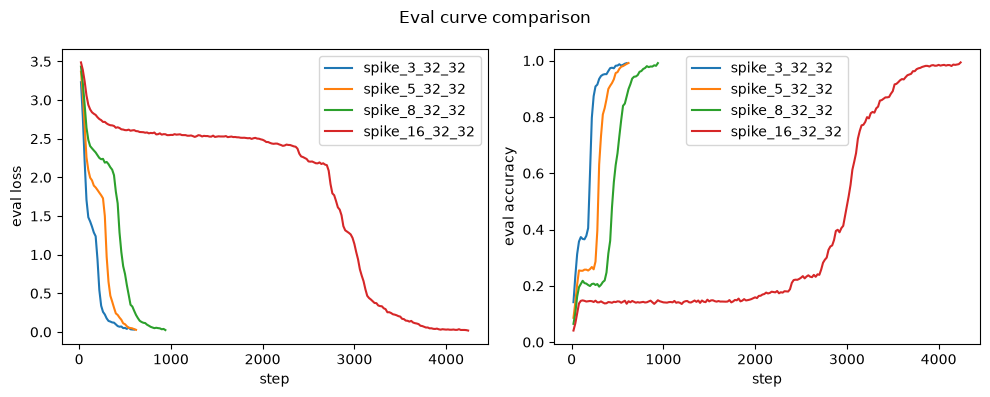

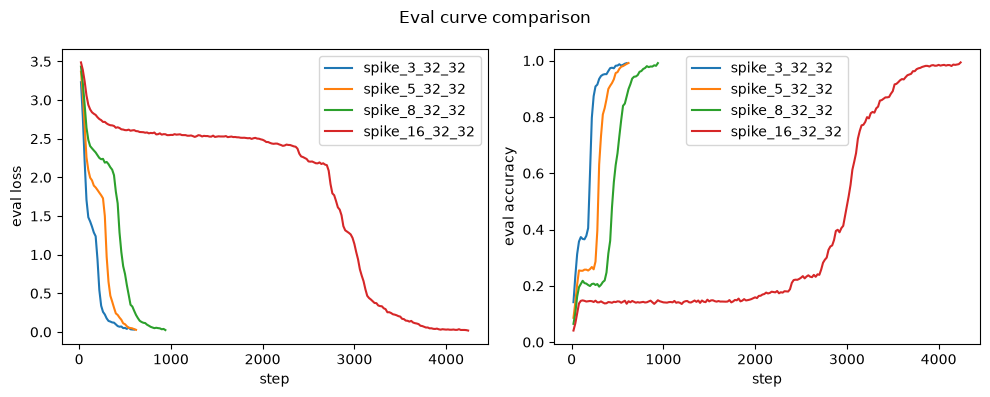

In [25]:
fig = plot_histories({name: r["history"] for name, r in runs.items()}, title="Eval curve comparison")
fig


## Attention heatmap evolution per run

For each run, build a fresh example sequence matching that run's own task config
(`num_kv_pairs`/`num_rounds`/`num_keys`/`num_values` can differ across runs), then replay its
checkpoints to show how the QK attention heatmap evolved over training.

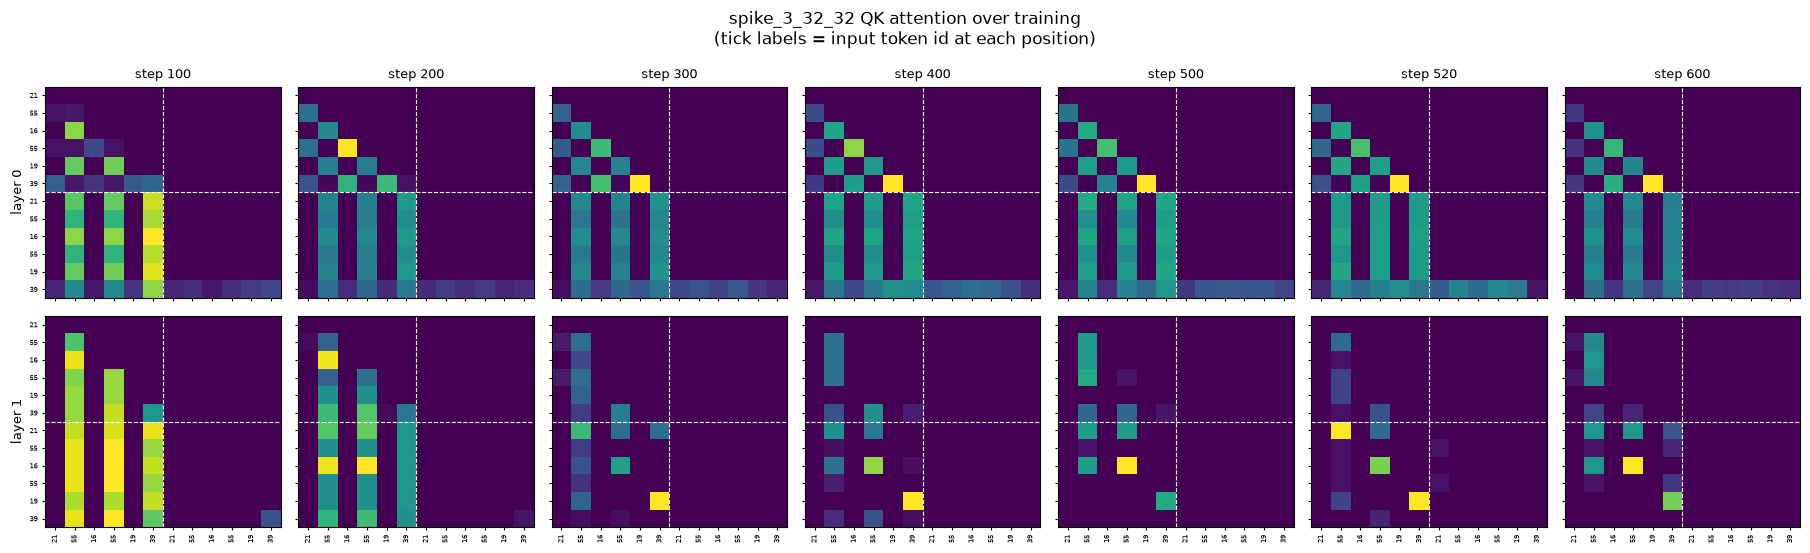

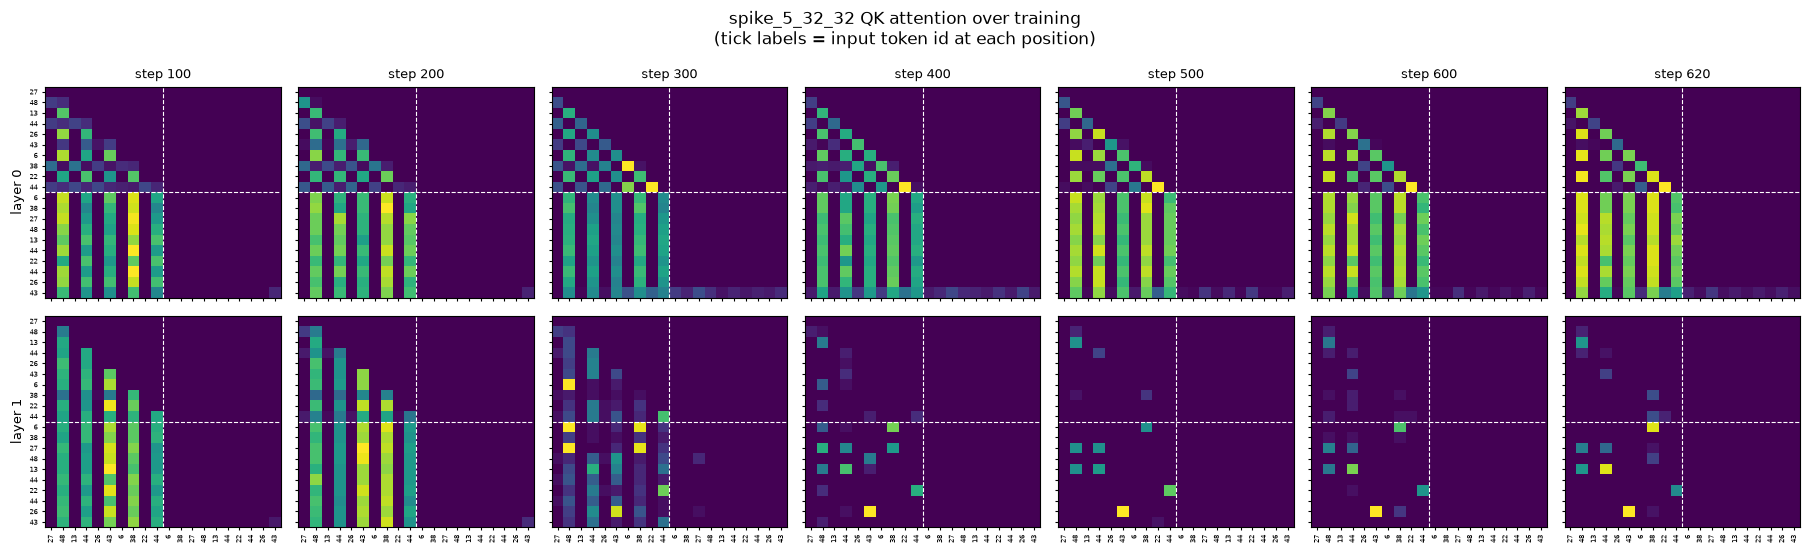

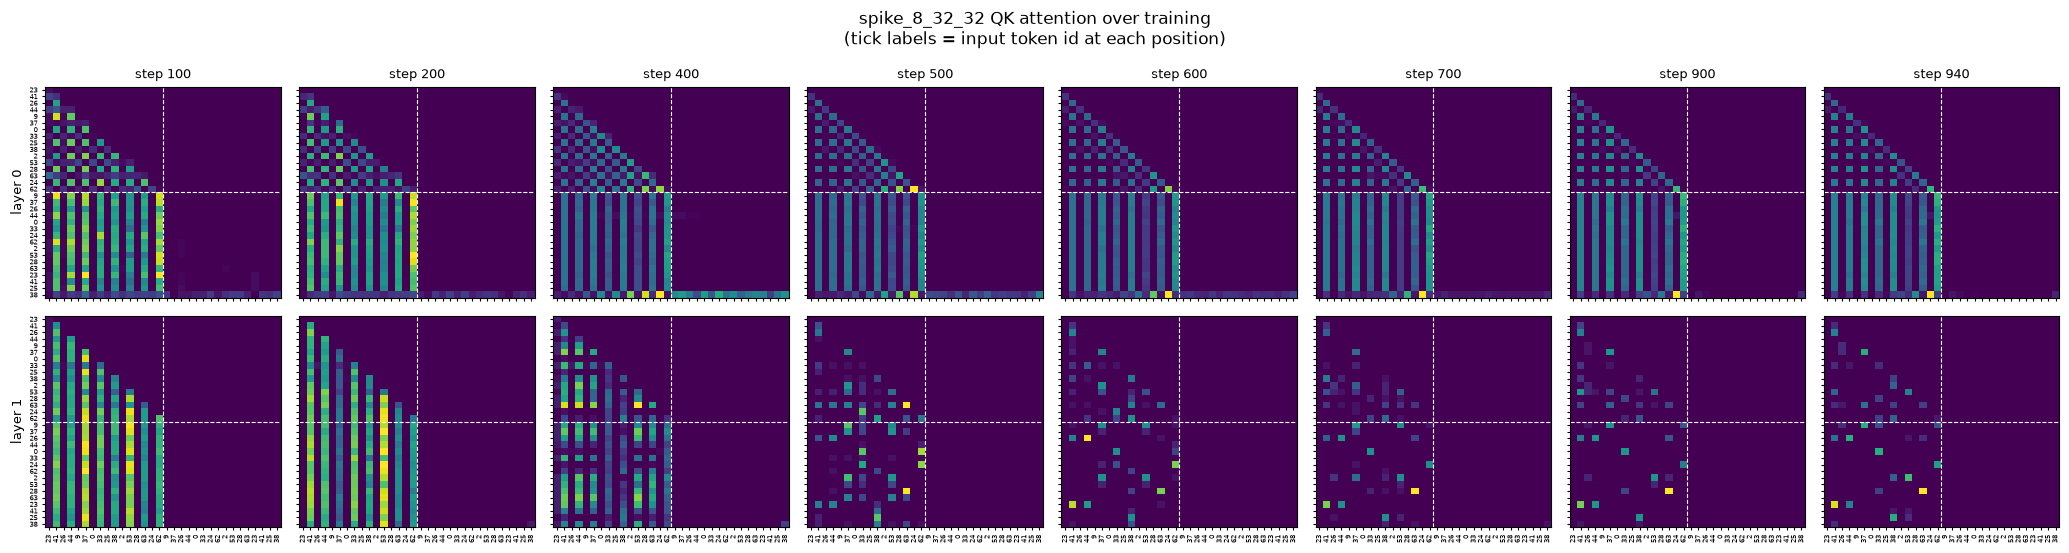

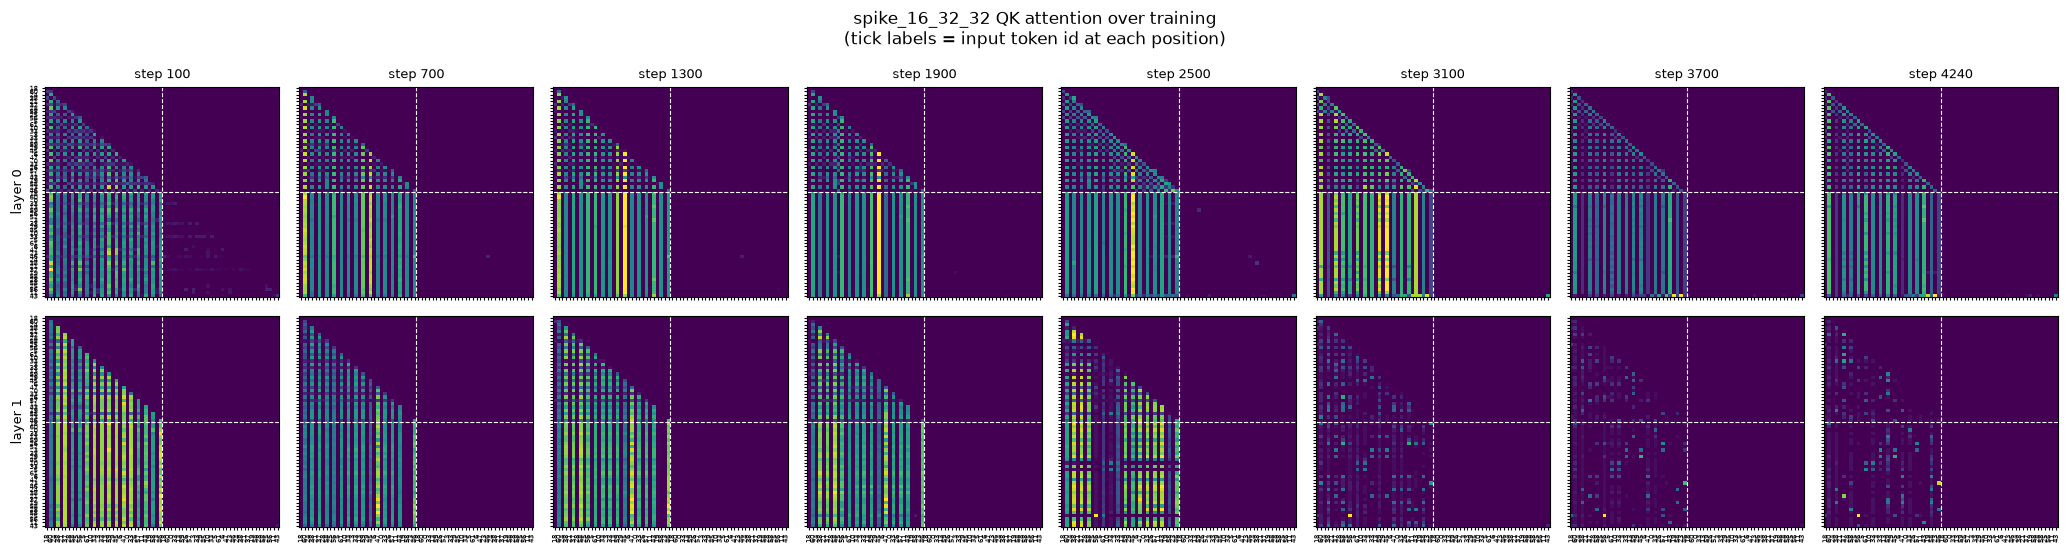

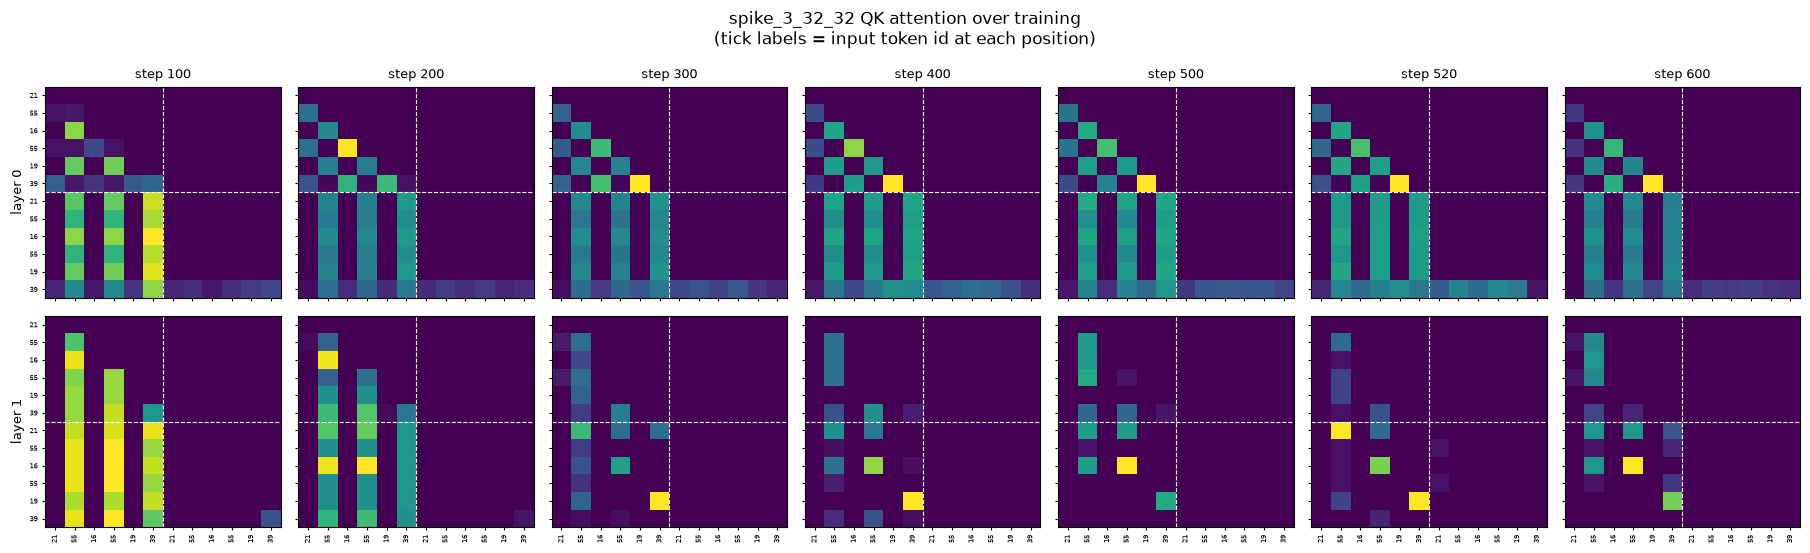

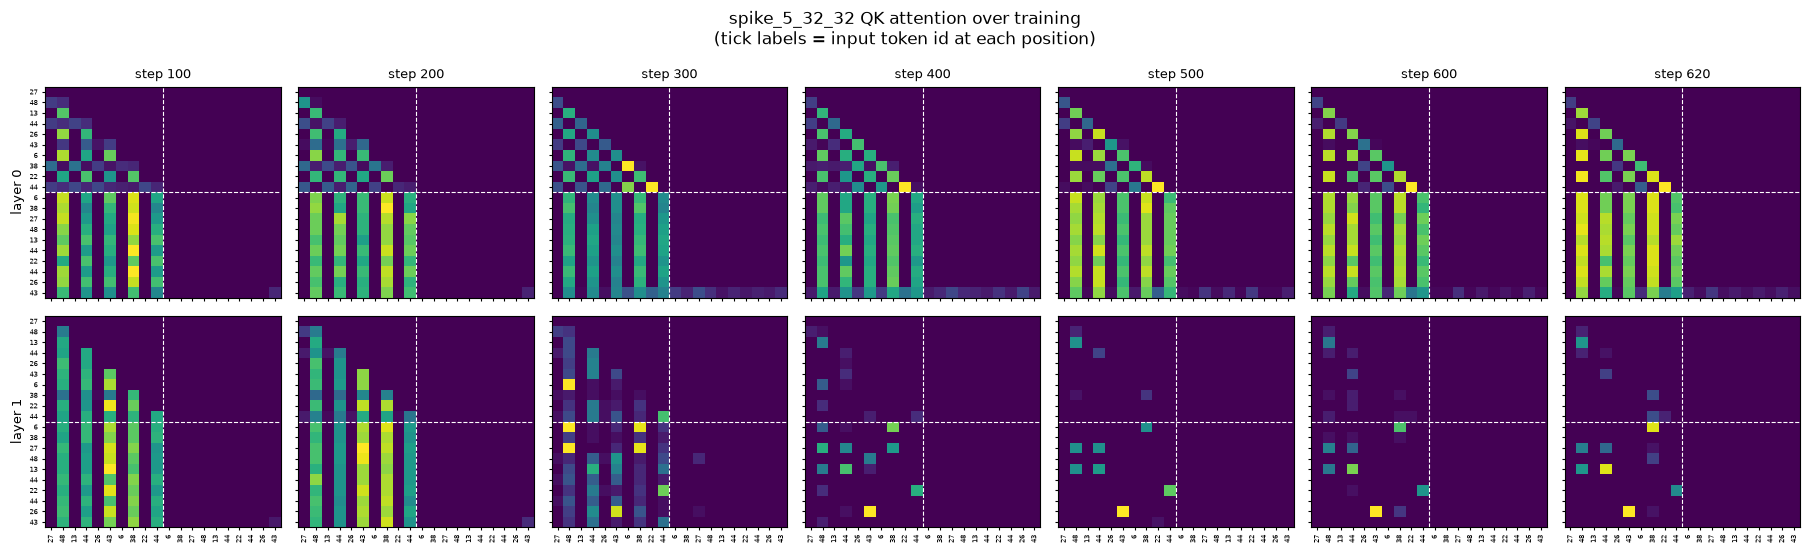

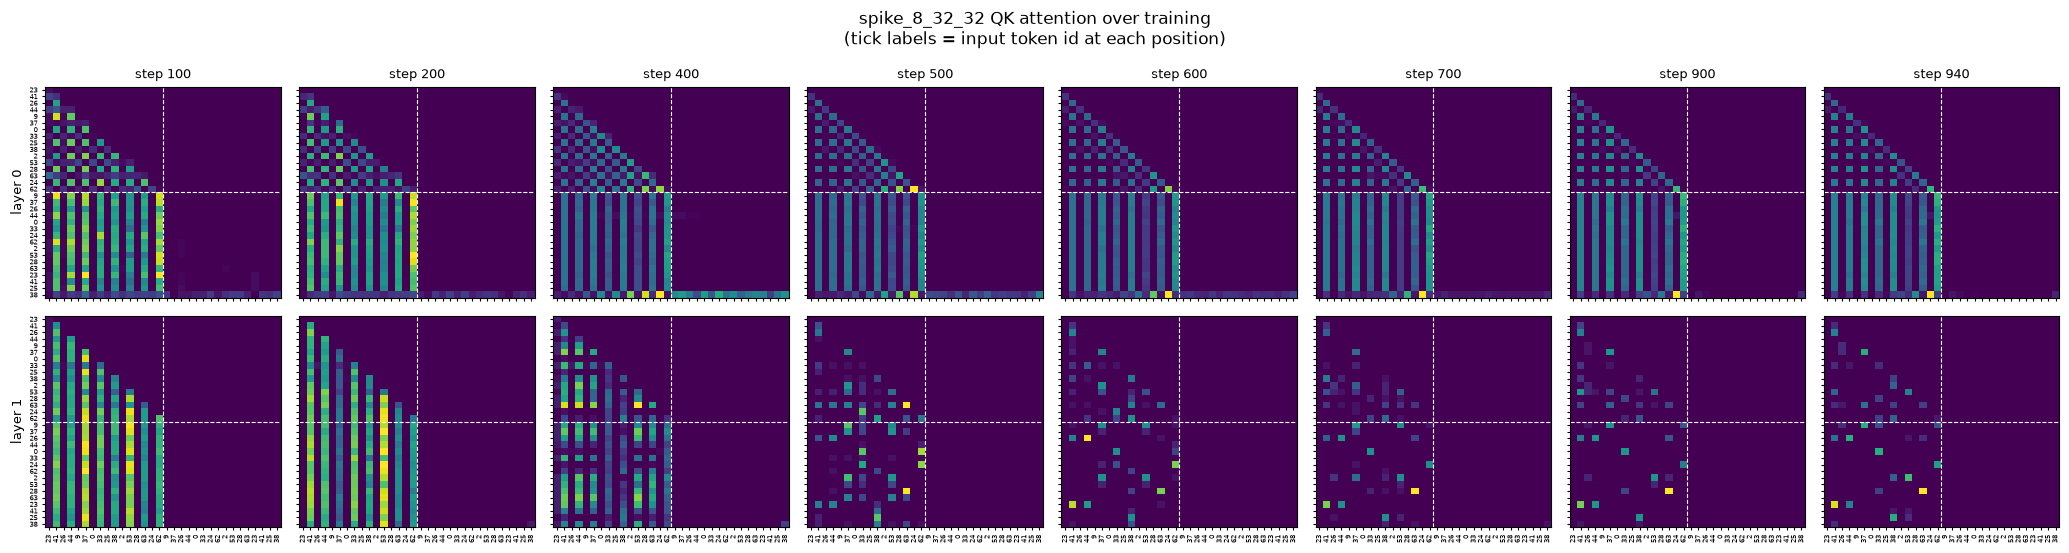

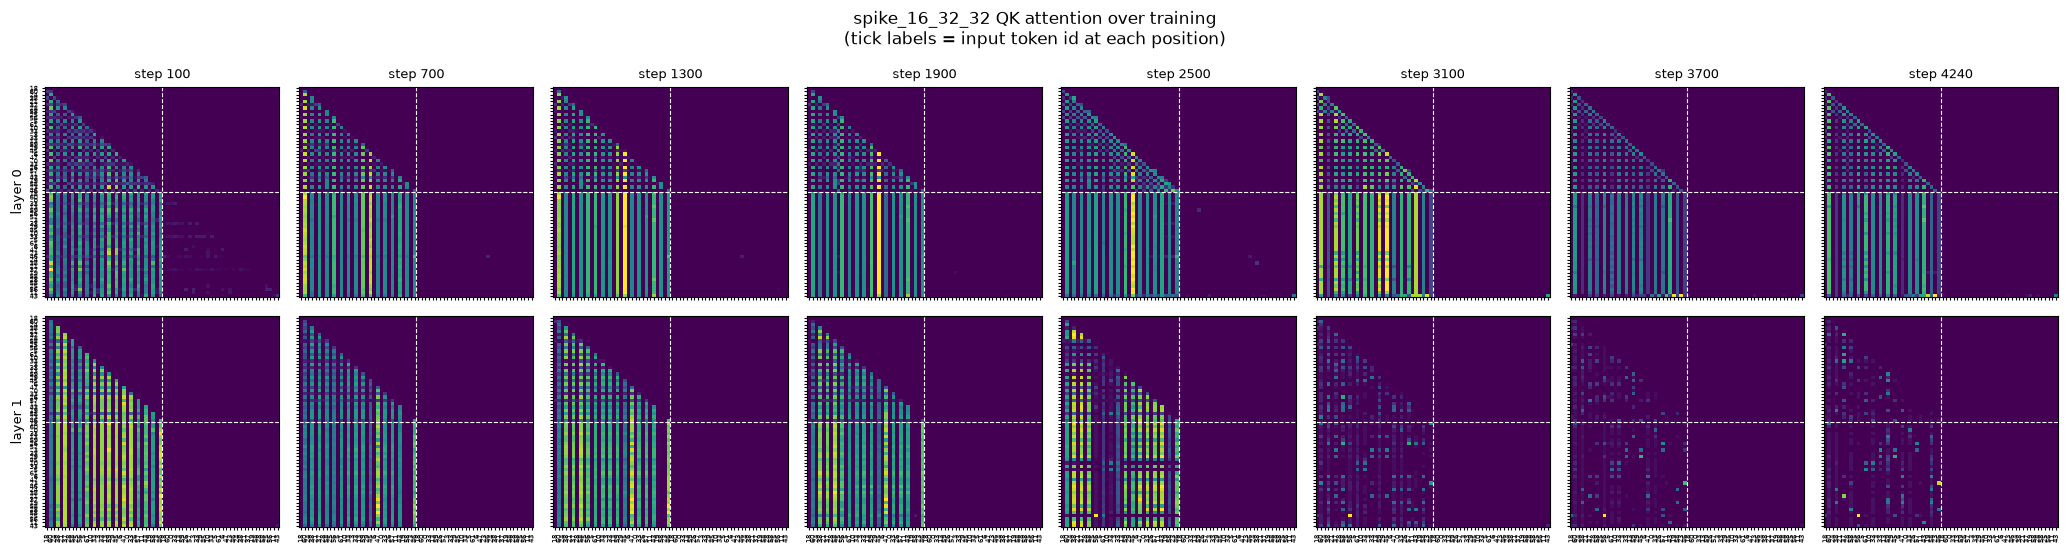

In [26]:
from IPython.display import display

figs = {}
for name, r in runs.items():
    config = r["config"]
    V = vocab_size(config["num_keys"], config["num_values"])
    L = seq_len(config["num_kv_pairs"], config["num_rounds"])

    model = build_model(config, max_len=L, vocab_sz=V).to(device)
    example_seq = generate_batch(
        1, config["num_kv_pairs"], config["num_rounds"],
        config["num_keys"], config["num_values"], device=device,
    )

    figs[name] = checkpoint_attn_grid(
        model, r["checkpoints"], example_seq, f"{name} QK attention over training",
        num_kv_pairs=config["num_kv_pairs"],
    )
    display(figs[name])
